Type	Examples
1.Personal Info-	Age, Gender, Ethnicity
2.Lifestyle-	Smoking, Diet, Sleep
3.Medical Conditions-	Diabetes, Hypertension
4.Brain Tests	-MMSE, FunctionalAssessment
5.Symptoms	-Forgetfulness, Confusion
6.Target	Diagnosis

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [34]:
df = pd.read_csv("alzheimers_disease_data.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2149, 33)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


In [35]:
print("\nDataset Info:\n")
print(df.info())
print("\nStatistical Summary:\n")
print(df.describe())
print("\nColumn Names:\n")
print(df.columns.tolist())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 

In [36]:
missing_values = df.isnull().sum()

In [37]:
missing_values

Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfulness                0
Diagnosi

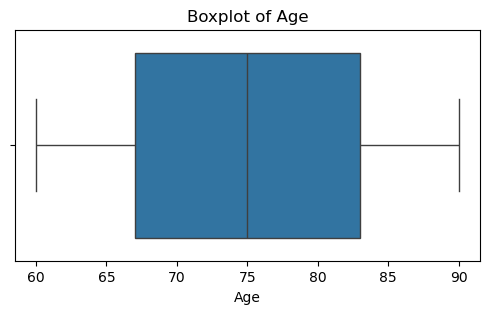

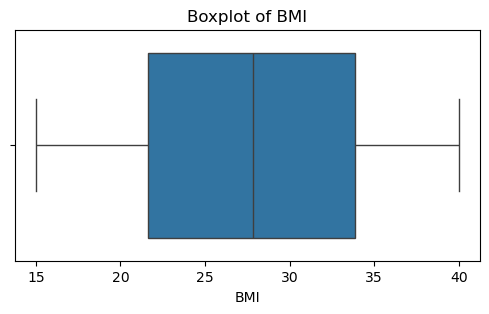

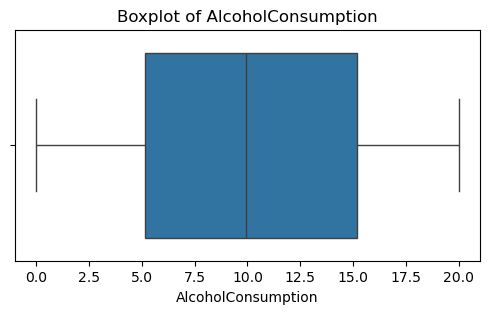

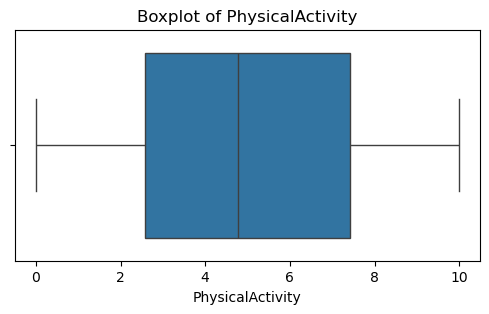

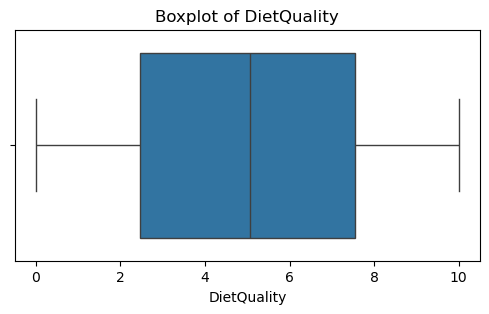

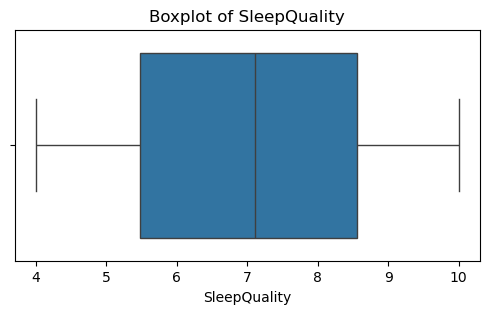

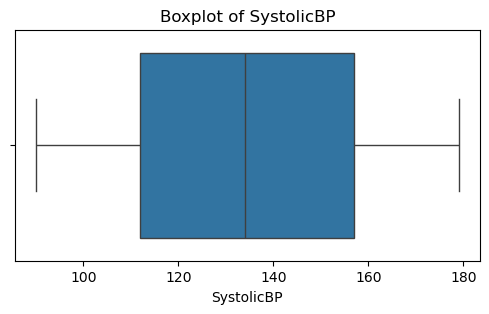

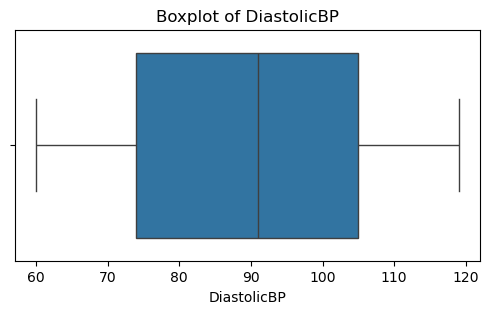

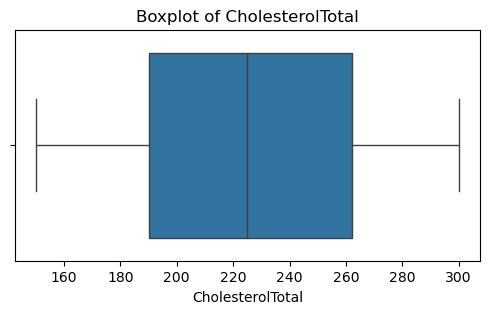

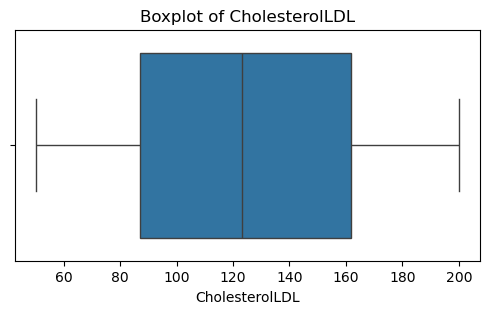

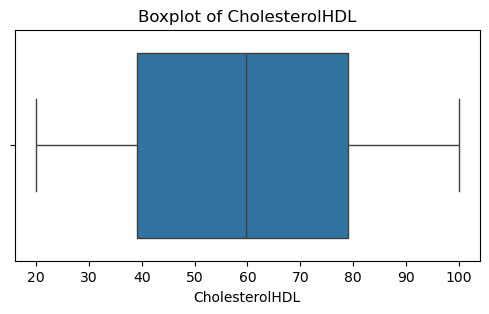

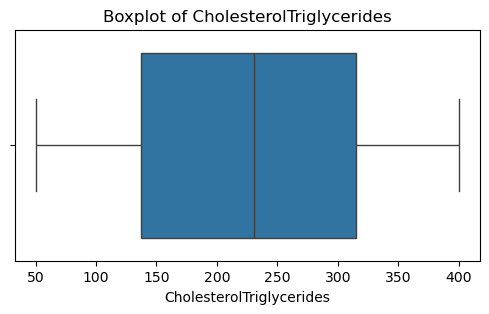

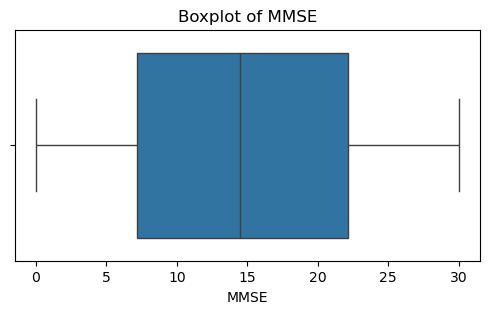

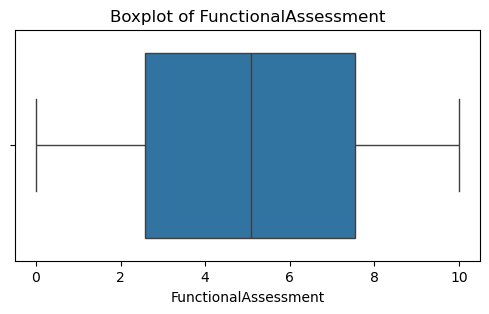

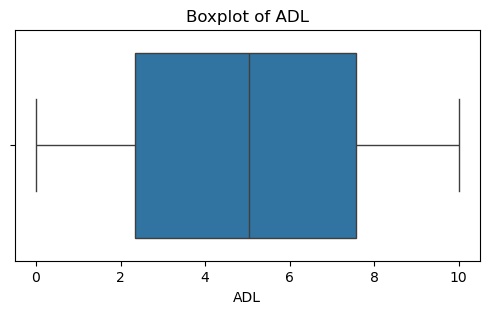

In [38]:
continuous_cols = [
    'Age',
    'BMI',
    'AlcoholConsumption',
    'PhysicalActivity',
    'DietQuality',
    'SleepQuality',
    'SystolicBP',
    'DiastolicBP',
    'CholesterolTotal',
    'CholesterolLDL',
    'CholesterolHDL',
    'CholesterolTriglycerides',
    'MMSE',
    'FunctionalAssessment',
    'ADL'
]

for col in continuous_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

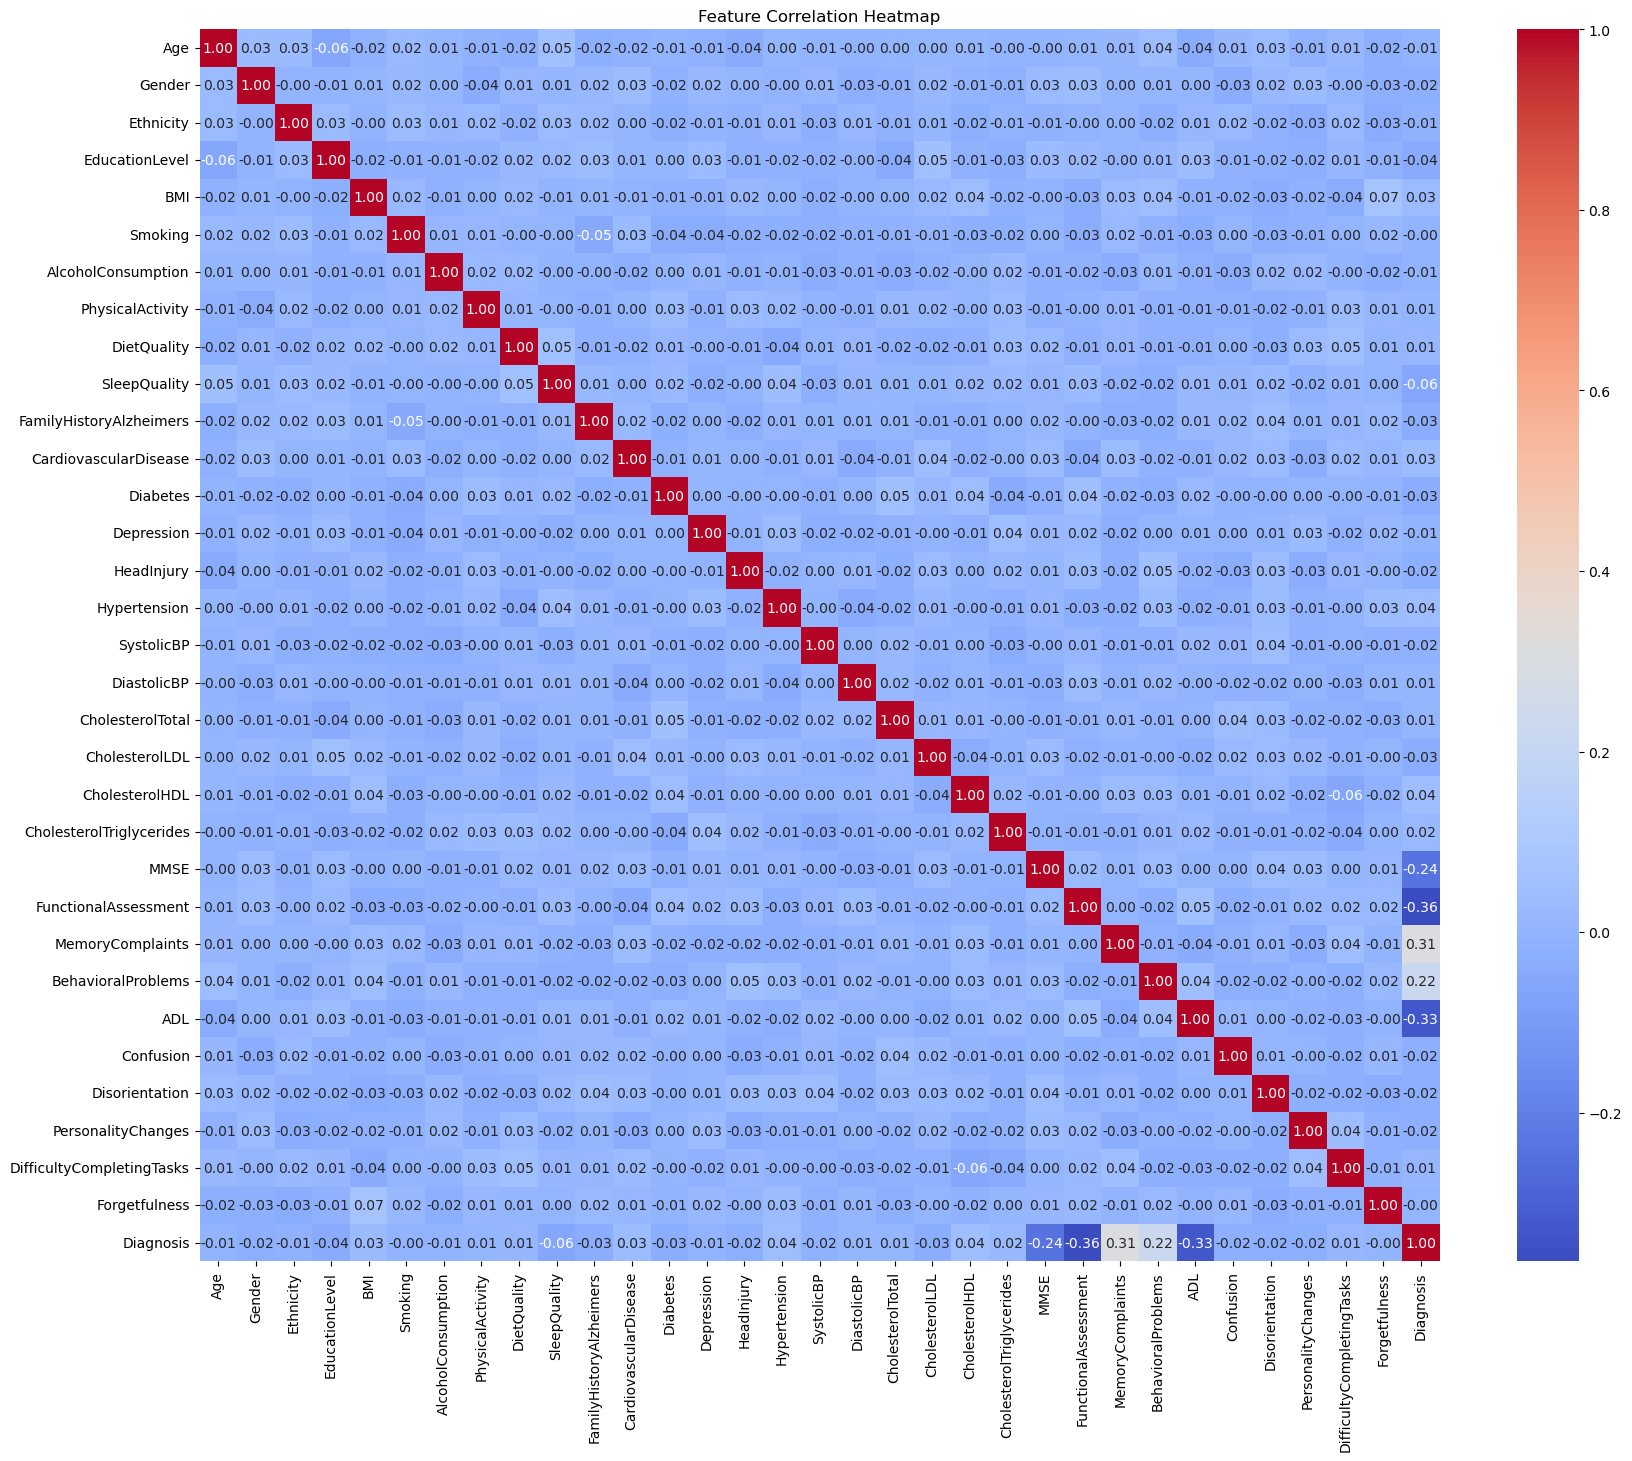

In [39]:
plt.figure(figsize=(20,16))
correlation_matrix = df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [40]:
leakage_features = [
    'Forgetfulness',
    'Confusion',
    'Disorientation',
    'BehavioralProblems',
    'PersonalityChanges',
    'DifficultyCompletingTasks',
    'MemoryComplaints'
]

risk_df = df.drop(
    columns=leakage_features
)

print("Risk Dataset Shape:")
print(risk_df.shape)

Risk Dataset Shape:
(2149, 26)


In [41]:
X_risk = risk_df.drop(
    "Diagnosis",
    axis=1
)
y_risk = risk_df["Diagnosis"]
print("X Shape:", X_risk.shape)
print("y Shape:", y_risk.shape)

X Shape: (2149, 25)
y Shape: (2149,)


In [42]:
from sklearn.model_selection import train_test_split

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(X_risk, y_risk,test_size=0.2,stratify=y_risk,random_state=42)
print("X_train Shape:", X_train_risk.shape)
print("X_test Shape:", X_test_risk.shape)
print("y_train Shape:", y_train_risk.shape)
print("y_test Shape:", y_test_risk.shape)

X_train Shape: (1719, 25)
X_test Shape: (430, 25)
y_train Shape: (1719,)
y_test Shape: (430,)


In [43]:
X_train_risk
X_test_risk
y_train_risk
y_test_risk

451     1
2080    1
1656    1
1070    1
830     1
       ..
1797    0
1424    0
108     1
1816    0
162     0
Name: Diagnosis, Length: 430, dtype: int64

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

xgb_model = XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,gamma=1,objective='binary:logistic',eval_metric='logloss',random_state=42)
xgb_model.fit(X_train_risk,y_train_risk)
print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [45]:
y_pred_xgb = xgb_model.predict(
    X_test_risk
)

y_prob_xgb = xgb_model.predict_proba(
    X_test_risk
)[:,1]

In [46]:
accuracy = accuracy_score(y_test_risk,y_pred_xgb)
precision = precision_score(y_test_risk,y_pred_xgb)
recall = recall_score(y_test_risk, y_pred_xgb)
f1 = f1_score(y_test_risk,y_pred_xgb)
auc = roc_auc_score(y_test_risk,y_prob_xgb)
print(" XGBOOST RESULTS ")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

 XGBOOST RESULTS 
Accuracy  : 0.8326
Precision : 0.8704
Recall    : 0.6184
F1 Score  : 0.7231
ROC-AUC   : 0.8699


In [47]:
print(
    classification_report(
        y_test_risk,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.82      0.95      0.88       278
           1       0.87      0.62      0.72       152

    accuracy                           0.83       430
   macro avg       0.85      0.78      0.80       430
weighted avg       0.84      0.83      0.82       430



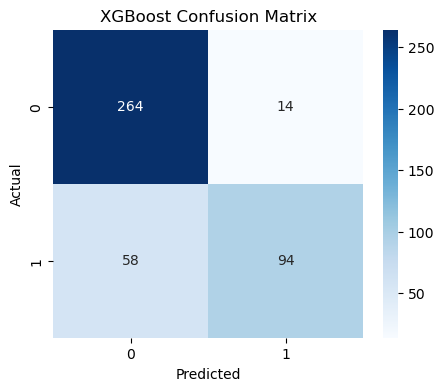

In [48]:
cm = confusion_matrix(
    y_test_risk,
    y_pred_xgb
)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [49]:
importance_df = pd.DataFrame({
    'Feature': X_train_risk.columns,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

                     Feature  Importance
23      FunctionalAssessment    0.124330
24                       ADL    0.121337
22                      MMSE    0.107111
12                  Diabetes    0.037113
20            CholesterolHDL    0.034742
18          CholesterolTotal    0.034235
6         AlcoholConsumption    0.032106
0                        Age    0.031819
7           PhysicalActivity    0.031341
9               SleepQuality    0.031029
8                DietQuality    0.030447
21  CholesterolTriglycerides    0.030298
17               DiastolicBP    0.029687
19            CholesterolLDL    0.029658
4                        BMI    0.029359
13                Depression    0.029092
3             EducationLevel    0.028131
16                SystolicBP    0.027863
5                    Smoking    0.027672
10   FamilyHistoryAlzheimers    0.026929
11     CardiovascularDisease    0.026670
2                  Ethnicity    0.025994
1                     Gender    0.025135
15              

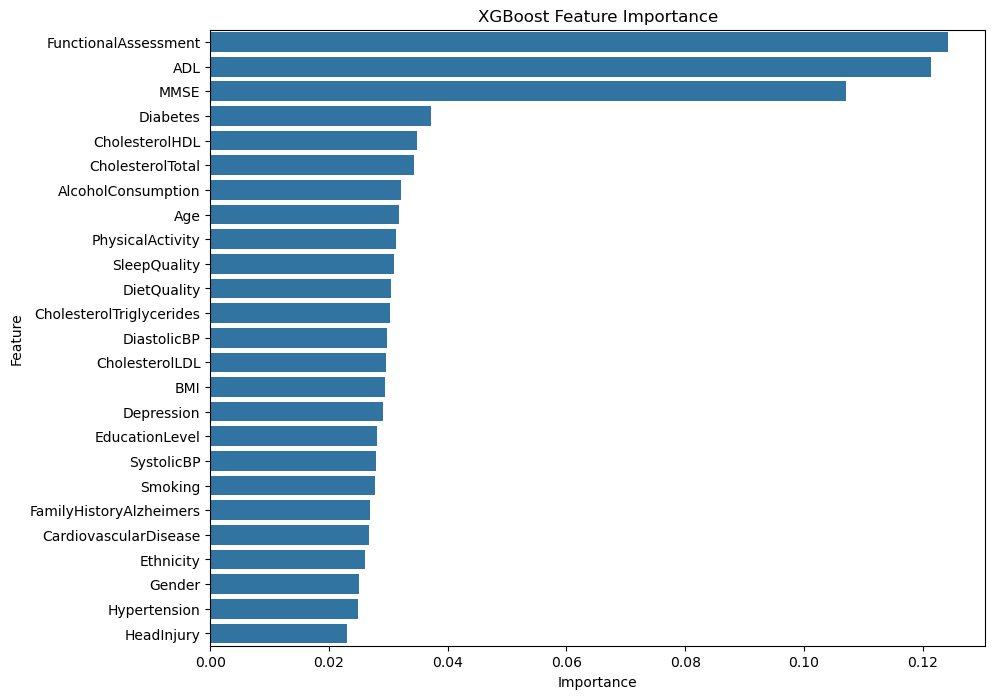

In [50]:
plt.figure(figsize=(10,8))
sns.barplot(  
    x='Importance', 
    y='Feature', 
    data=importance_df
)
plt.title("XGBoost Feature Importance")
plt.show()

In [51]:
import joblib
joblib.dump(
    xgb_model,
    "alzheimers_xgboost_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [52]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 1],
    'min_child_weight': [1, 3, 5]
}

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_risk,
    y_train_risk
)

print("Best Parameters:")
print(random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]


Best Parameters:
{'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.8}


In [53]:
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_risk)
y_prob_best = best_xgb.predict_proba(
    X_test_risk
)[:,1]

In [54]:
print(y_risk.value_counts())

Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [55]:
scale_pos_weight = (
    len(y_train_risk[y_train_risk == 0]) /
    len(y_train_risk[y_train_risk == 1])
)

In [56]:
scale_pos_weight = (
    len(y_train_risk[y_train_risk == 0]) /
    len(y_train_risk[y_train_risk == 1])
)
print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 1.8273026315789473


In [57]:
from xgboost import XGBClassifier
final_xgb = XGBClassifier(
n_estimators=300,
max_depth=4,
learning_rate=0.03,
subsample=0.8,
colsample_bytree=0.8,
gamma=0.1,
min_child_weight=3,
scale_pos_weight=scale_pos_weight,
objective='binary:logistic',
eval_metric='logloss',
random_state=42
)

final_xgb.fit(
 X_train_risk,
 y_train_risk
)

print("Final Tuned XGBoost Model Trained!")

Final Tuned XGBoost Model Trained!


In [58]:
y_pred_final = final_xgb.predict(
    X_test_risk
)
y_prob_final = final_xgb.predict_proba(
    X_test_risk
)[:,1]

In [59]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
accuracy = accuracy_score(
    y_test_risk,
    y_pred_final
)
precision = precision_score(
    y_test_risk,
    y_pred_final
)

recall = recall_score(
    y_test_risk,
    y_pred_final
)

f1 = f1_score(
    y_test_risk,
    y_pred_final
)

auc = roc_auc_score(
    y_test_risk,
    y_prob_final
)

print("FINAL XGBOOST RESULTS ")

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

print(f"ROC-AUC   : {auc:.4f}")

FINAL XGBOOST RESULTS 
Accuracy  : 0.8140
Precision : 0.7687
Recall    : 0.6776
F1 Score  : 0.7203
ROC-AUC   : 0.8786


In [60]:

print(
    classification_report(
        y_test_risk,
        y_pred_final
    )
)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       278
           1       0.77      0.68      0.72       152

    accuracy                           0.81       430
   macro avg       0.80      0.78      0.79       430
weighted avg       0.81      0.81      0.81       430



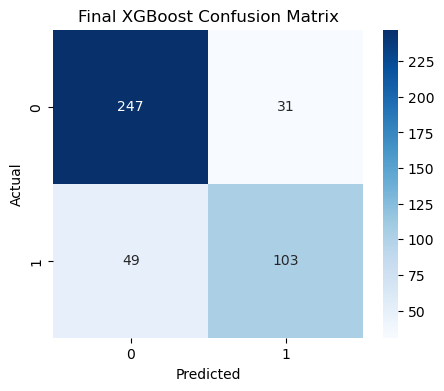

In [61]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_risk,
    y_pred_final
)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Final XGBoost Confusion Matrix")

plt.show()

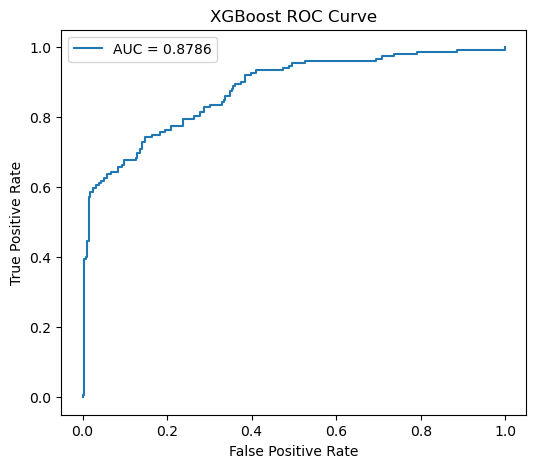

In [62]:

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(

    y_test_risk,

    y_prob_final
)

auc_score = roc_auc_score(

    y_test_risk,

    y_prob_final
)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f'AUC = {auc_score:.4f}'
)


plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC Curve")

plt.legend()

plt.show()

In [63]:
from sklearn.calibration import CalibratedClassifierCV

# Create calibrated model
calibrated_model = CalibratedClassifierCV(
    final_xgb,
    method='sigmoid',
    cv=5
)

# Train calibrated model
calibrated_model.fit(
    X_train_risk,
    y_train_risk
)

print("Calibrated Model Ready!")

ValueError: XGBClassifier should either be a classifier to be used with response_method=['decision_function', 'predict_proba'] or the response_method should be 'predict'. Got a regressor with response_method=['decision_function', 'predict_proba'] instead.

In [ ]:
y_prob_calibrated = calibrated_model.predict_proba(
    X_test_risk
)[:,1]

print(y_prob_calibrated[:10])

[0.88004761 0.46113567 0.64580965 0.70525846 0.87382977 0.1825271
 0.60145418 0.29365677 0.10484612 0.5740598 ]


In [ ]:
import numpy as np

confidence_scores = np.maximum(
    y_prob_calibrated,
    1 - y_prob_calibrated
)

print(confidence_scores[:10])

[0.88004761 0.53886433 0.64580965 0.70525846 0.87382977 0.8174729
 0.60145418 0.70634323 0.89515388 0.5740598 ]


In [ ]:
confidence_labels = []

for score in confidence_scores:
    
    if score > 0.85:
        confidence_labels.append("High Confidence")
        
    elif score > 0.65:
        confidence_labels.append("Moderate Confidence")
        
    else:
        confidence_labels.append("Low Confidence")

print(confidence_labels[:10])

['High Confidence', 'Low Confidence', 'Low Confidence', 'Moderate Confidence', 'High Confidence', 'Moderate Confidence', 'Low Confidence', 'Moderate Confidence', 'High Confidence', 'Low Confidence']


In [ ]:
patient_index = 0

prediction = calibrated_model.predict(
    X_test_risk.iloc[[patient_index]]
)[0]

probability = calibrated_model.predict_proba(
    X_test_risk.iloc[[patient_index]]
)[0][1]

confidence = confidence_labels[patient_index]

print("===== Alzheimer Clinical AI Report =====")
print()

print(f"Prediction: {prediction}")
print(f"Risk Probability: {probability:.2f}")
print(f"Confidence Level: {confidence}")

===== Alzheimer Clinical AI Report =====

Prediction: 1
Risk Probability: 0.88
Confidence Level: High Confidence


In [64]:
import shap

explainer = shap.Explainer(
    final_xgb,
    X_train_risk
)

shap_values = explainer(
    X_test_risk
)

print("SHAP Working Successfully!")



SHAP Working Successfully!


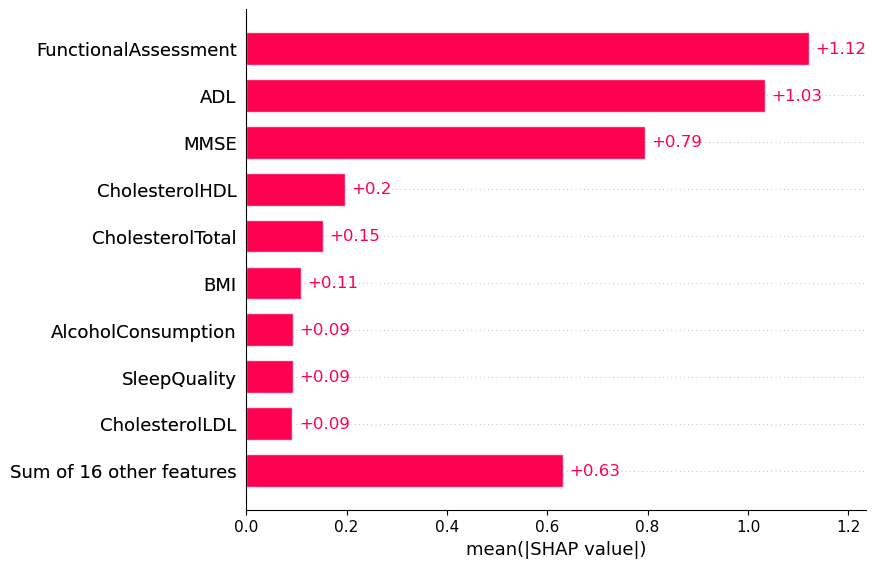

In [65]:
shap.plots.bar(shap_values)

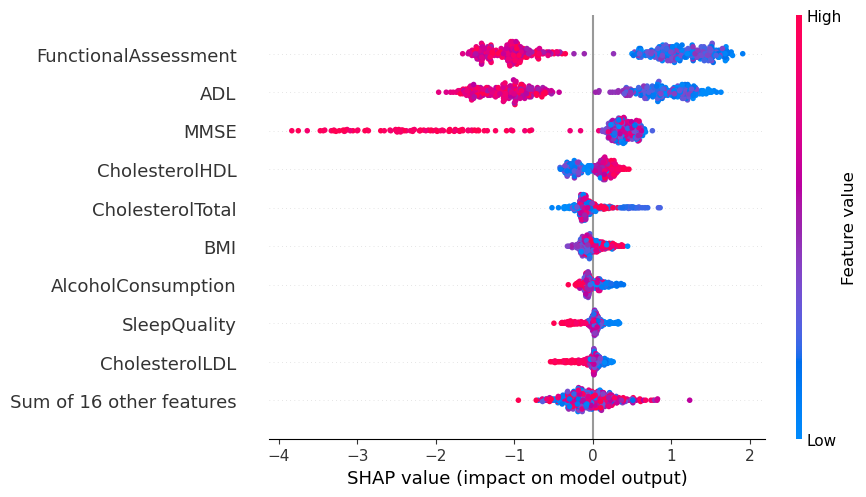

In [66]:
shap.plots.beeswarm(shap_values)

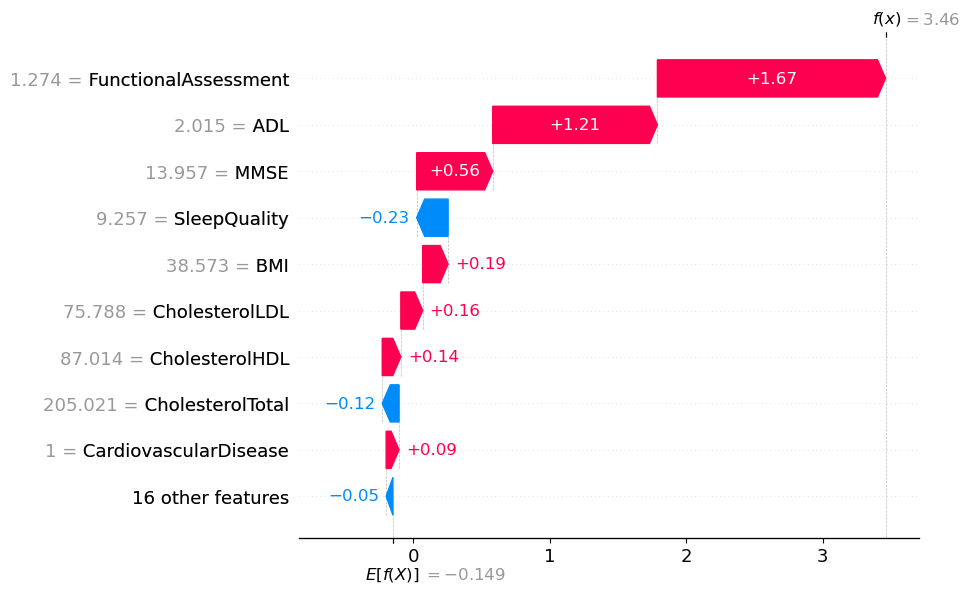

In [67]:
shap.plots.waterfall(
    shap_values[0]
)

In [ ]:
import dice_ml
from dice_ml import Dice

In [ ]:
train_dataset = X_train_risk.copy()

train_dataset['Diagnosis'] = y_train_risk

In [ ]:
d = dice_ml.Data(
    dataframe=train_dataset,
    continuous_features=list(X_train_risk.columns),
    outcome_name='Diagnosis'
)

In [ ]:
m = dice_ml.Model(
    model=final_xgb,
    backend='sklearn'
)

In [ ]:
exp = Dice(
    d,
    m,
    method='random'
)

In [ ]:
query_instance = X_test_risk.iloc[[0]]

In [ ]:
counterfactuals = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class='opposite'
)

100%|██████████| 1/1 [00:00<00:00,  2.05it/s]


In [ ]:
counterfactuals.visualize_as_dataframe()

Query instance (original outcome : 1)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,ADL,Diagnosis
0,69,1,0,3,38.573254,1,5.886069,2.273392,7.289339,9.257138,...,118,67,205.020798,75.788269,87.013855,310.271698,13.957099,1.273793,2.014531,1



Diverse Counterfactual set (new outcome: 0)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,ADL,Diagnosis
0,69,1,0,3,38.573252,1,5.88607,2.273392,7.289339,9.257138,...,118,67,205.020791,75.788267,87.013855,310.271705,13.957099,1.273793,7.256366,0
1,69,1,0,3,38.573252,1,5.88607,2.273392,7.289339,9.257138,...,118,67,205.020791,75.788267,87.013855,310.271705,13.957099,5.279110,2.014531,0
2,69,1,0,3,38.573252,1,5.88607,2.273392,7.289339,9.257138,...,125,67,205.020791,75.788267,87.013855,310.271705,27.092300,1.273793,2.014531,0


In [ ]:
import pandas as pd

concept_df = pd.DataFrame()

In [ ]:
concept_df['CognitiveDecline'] = (
    X_train_risk['MMSE'] < 24
).astype(int)

In [ ]:
concept_df['FunctionalImpairment'] = (
    X_train_risk['FunctionalAssessment'] < 5
).astype(int)

In [ ]:
concept_df['CardioRisk'] = (
    (
        X_train_risk['Hypertension'] +
        X_train_risk['CardiovascularDisease'] +
        X_train_risk['Diabetes']
    ) >= 1
).astype(int)

In [ ]:
concept_df['LifestyleRisk'] = (
    (
        (X_train_risk['Smoking'] > 0) |
        (X_train_risk['SleepQuality'] < 5) |
        (X_train_risk['PhysicalActivity'] < 3)
    )
).astype(int)

In [ ]:
concept_df['CholesterolRisk'] = (
    X_train_risk['CholesterolTotal'] > 200
).astype(int)

In [ ]:
from xgboost import XGBClassifier

concept_models = {}

In [ ]:
for concept in concept_df.columns:
    
    model = XGBClassifier(
        random_state=42
    )
    
    model.fit(
        X_train_risk,
        concept_df[concept]
    )
    
    concept_models[concept] = model

print("Concept Models Trained!")

Concept Models Trained!


In [ ]:
concept_predictions_test = pd.DataFrame()

for concept, model in concept_models.items():
    
    concept_predictions_test[concept] = model.predict(
        X_test_risk
    )

In [ ]:
final_concept_model = XGBClassifier(
    random_state=42
)

final_concept_model.fit(
    concept_predictions_test,
    y_test_risk
)

print("Final Concept-Based Model Ready!")

Final Concept-Based Model Ready!


In [ ]:
new_patient_concepts = pd.DataFrame()

for concept, model in concept_models.items():
    
    new_patient_concepts[concept] = model.predict(
        X_test_risk.iloc[[0]]
    )

In [ ]:
final_prediction = final_concept_model.predict(
    new_patient_concepts
)

print(final_prediction)

[1]


In [ ]:
print("===== Clinical Concept Reasoning =====")

print(new_patient_concepts)

===== Clinical Concept Reasoning =====
   CognitiveDecline  FunctionalImpairment  CardioRisk  LifestyleRisk  \
0                 1                     1           1              1   

   CholesterolRisk  
0                1  


In [ ]:
ensemble_models = []

In [ ]:
from xgboost import XGBClassifier
import random

ensemble_models = []

for seed in range(10):

    model = XGBClassifier(
        n_estimators=random.choice([100, 200, 300]),
        max_depth=random.choice([3, 4, 5, 6]),
        learning_rate=random.choice([0.01, 0.03, 0.05]),
        subsample=random.choice([0.7, 0.8, 0.9]),
        colsample_bytree=random.choice([0.7, 0.8, 0.9]),
        gamma=random.choice([0, 0.1, 0.3]),
        min_child_weight=random.choice([1, 3, 5]),
        random_state=seed,
        objective='binary:logistic',
        eval_metric='logloss'
    )

    model.fit(
        X_train_risk,
        y_train_risk
    )

    ensemble_models.append(model)

print("Diverse Ensemble Trained!")

Diverse Ensemble Trained!


In [ ]:
all_probabilities = []

for model in ensemble_models:

    probs = model.predict_proba(
        X_test_risk
    )[:,1]

    all_probabilities.append(probs)

In [ ]:
import numpy as np

all_probabilities = np.array(
    all_probabilities
)

In [ ]:
mean_prediction = np.mean(
    all_probabilities,
    axis=0

)

In [ ]:
uncertainty = np.std(
    all_probabilities,
    axis=0
)

In [ ]:
for i in range(5):
    
    print(f"Patient {i}")
    
    print(
        f"Mean Risk: {mean_prediction[i]:.2f}"
    )
    
    print(
        f"Uncertainty: {uncertainty[i]:.4f}"
    )
    
    print()

Patient 0
Mean Risk: 0.86
Uncertainty: 0.1238

Patient 1
Mean Risk: 0.39
Uncertainty: 0.0494

Patient 2
Mean Risk: 0.53
Uncertainty: 0.0786

Patient 3
Mean Risk: 0.65
Uncertainty: 0.0724

Patient 4
Mean Risk: 0.85
Uncertainty: 0.1214



In [ ]:
import shap
import xgboost
import numpy as np

print(shap.__version__)
print(xgboost.__version__)
print(np.__version__)

0.44.1
2.0.3
1.26.4
